In [16]:
# ELEC3612: Pattern Recognition and Machine Intelligence
## Assignment 1 — Machine Learning Model: Implementation and Reporting


In [17]:
## Section 1: Dataset Download
## Download the Body Signal of Smoking dataset from Kaggle using the KaggleHub API.

In [18]:
import kagglehub
path = kagglehub.dataset_download("kukuroo3/body-signal-of-smoking")
print("Dataset downloaded to:", path)

Dataset downloaded to: /root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2


In [19]:
## Section 2: Data Loading and Preprocessing
# Load the dataset, inspect its structure, encode categorical variables,
# remove duplicates, scale features, and perform an 80/20 stratified train-test split.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv("/root/.cache/kagglehub/datasets/kukuroo3/body-signal-of-smoking/versions/2/smoking.csv")
print("Shape:", df.shape)
df.head()

Shape: (55692, 27)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,81.3,1.2,1.0,1.0,1.0,...,12.9,1.0,0.7,18.0,19.0,27.0,Y,0,Y,0
1,1,F,40,160,60,81.0,0.8,0.6,1.0,1.0,...,12.7,1.0,0.6,22.0,19.0,18.0,Y,0,Y,0
2,2,M,55,170,60,80.0,0.8,0.8,1.0,1.0,...,15.8,1.0,1.0,21.0,16.0,22.0,Y,0,N,1
3,3,M,40,165,70,88.0,1.5,1.5,1.0,1.0,...,14.7,1.0,1.0,19.0,26.0,18.0,Y,0,Y,0
4,4,F,40,155,60,86.0,1.0,1.0,1.0,1.0,...,12.5,1.0,0.6,16.0,14.0,22.0,Y,0,N,0


In [21]:
# ── 2. BASIC INFO ─────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Distribution ===")
print(df['smoking'].value_counts())

=== Data Types ===
ID                       int64
gender                  object
age                      int64
height(cm)               int64
weight(kg)               int64
waist(cm)              float64
eyesight(left)         float64
eyesight(right)        float64
hearing(left)          float64
hearing(right)         float64
systolic               float64
relaxation             float64
fasting blood sugar    float64
Cholesterol            float64
triglyceride           float64
HDL                    float64
LDL                    float64
hemoglobin             float64
Urine protein          float64
serum creatinine       float64
AST                    float64
ALT                    float64
Gtp                    float64
oral                    object
dental caries            int64
tartar                  object
smoking                  int64
dtype: object

=== Missing Values ===
ID                     0
gender                 0
age                    0
height(cm)             0
weight

In [22]:
# ── 3. ENCODE CATEGORICAL COLUMNS ────────────────────────────────────────────
le = LabelEncoder()

# Encode gender: F=0, M=1
df['gender'] = le.fit_transform(df['gender'])

# Encode binary Y/N columns
df['tartar'] = df['tartar'].map({'Y': 1, 'N': 0})
df['oral']   = df['oral'].map({'Y': 1, 'N': 0})

print("After encoding:")
print(df[['gender', 'tartar', 'oral']].head())

# ── 4. DROP ID COLUMN ─────────────────────────────────────────────────────────
df = df.drop(columns=['ID'])
print("\nShape after dropping ID:", df.shape)

# ── 5. REMOVE DUPLICATES ─────────────────────────────────────────────────────
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

After encoding:
   gender  tartar  oral
0       0       1     1
1       0       1     1
2       1       0     1
3       1       1     1
4       0       0     1

Shape after dropping ID: (55692, 26)
Duplicate rows: 11140
Shape after removing duplicates: (44552, 26)


In [23]:
# ── 6. FEATURE / TARGET SPLIT ────────────────────────────────────────────────
X = df.drop(columns=['smoking'])
y = df['smoking']
print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# ── 7. SCALE NUMERIC FEATURES ────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("\nScaled features (first 5 rows):")
X_scaled.head()

Features shape: (44552, 25)
Target distribution:
 smoking
0    28200
1    16352
Name: count, dtype: int64

Scaled features (first 5 rows):


,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar
0,-1.322730,-0.348306,-1.049840,-0.458797,-0.083764,0.385696,-0.016634,-0.162122,-0.163502,-0.550028,...,0.267772,-1.100576,-0.214899,-0.823149,-0.430333,-0.254608,-0.257595,0.0,-0.521054,0.894025
1,-1.322730,-0.348306,-0.506278,-0.458797,-0.116098,-0.433757,-0.835029,-0.162122,-0.163502,-0.184764,...,0.292200,-1.228384,-0.214899,-1.265455,-0.220767,-0.254608,-0.435028,0.0,-0.521054,0.894025
2,0.756012,0.892485,0.580848,-0.458797,-0.223876,-0.433757,-0.425831,-0.162122,-0.163502,1.203240,...,0.878455,0.752639,-0.214899,0.503769,-0.273158,-0.349082,-0.356169,0.0,-0.521054,-1.118537
3,0.756012,-0.348306,0.037285,0.321011,0.638353,1.000285,1.006361,-0.162122,-0.163502,-1.572768,...,2.710501,0.049695,-0.214899,0.503769,-0.377941,-0.034168,-0.435028,0.0,-0.521054,0.894025
4,-1.322730,-0.348306,-1.049840,-0.458797,0.422795,-0.024031,-0.016634,-0.162122,-0.163502,-0.111711,...,-0.196346,-1.356192,-0.214899,-1.265455,-0.535115,-0.412064,-0.356169,0.0,-0.521054,-1.118537


In [24]:
# ── 8. TRAIN-TEST SPLIT (80/20, stratified, seed=42) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (35641, 25)
Test size:  (8911, 25)


In [25]:
## Section 3: Exploratory Data Analysis (EDA)
# Visualise the target class distribution, gender vs smoking, and age distribution
# to understand the dataset before modelling.

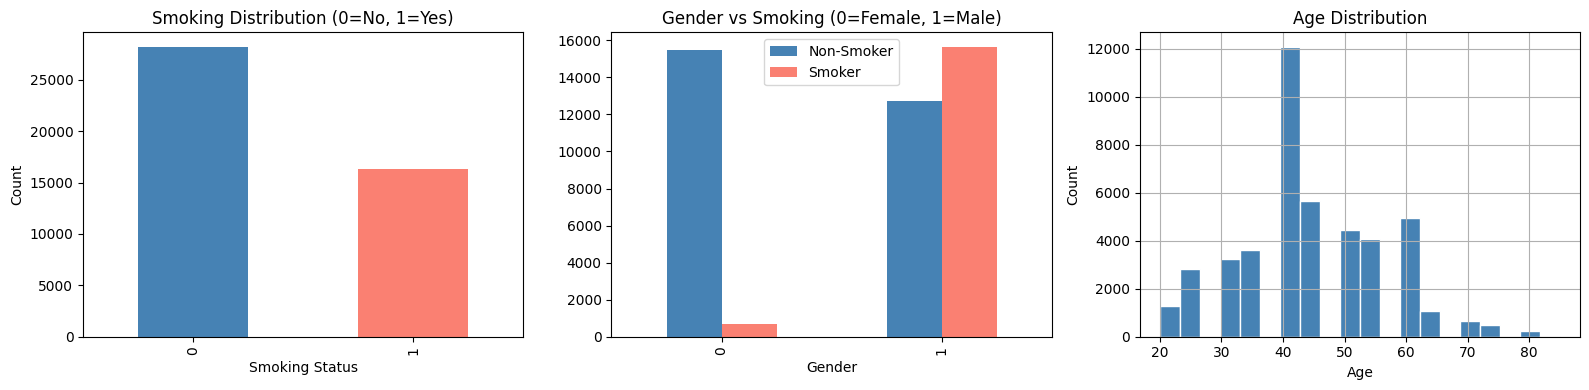

In [26]:
# ── 9. EDA VISUALISATIONS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target class distribution
y.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Smoking Distribution (0=No, 1=Yes)')
axes[0].set_xlabel('Smoking Status')
axes[0].set_ylabel('Count')

# Gender vs Smoking
pd.crosstab(df['gender'], df['smoking']).plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Gender vs Smoking (0=Female, 1=Male)')
axes[1].set_xlabel('Gender')
axes[1].legend(['Non-Smoker', 'Smoker'])

# Age distribution
df['age'].hist(ax=axes[2], bins=20, color='steelblue', edgecolor='white')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [27]:
## Section 4: Model Imports and Evaluation Helper
# Import all required ML models and define a reusable evaluation function
# that prints metrics and plots a confusion matrix for any given model.

In [28]:
# ── MODEL IMPORTS ─────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier,
                               AdaBoostClassifier, GradientBoostingClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              silhouette_score, adjusted_rand_score,
                              adjusted_mutual_info_score)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')
print("All imports successful!")

All imports successful!


In [29]:
# ── EVALUATION HELPER FUNCTION ────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    """Print accuracy, precision, recall, F1 and plot confusion matrix."""
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score : {f1_score(y_true, y_pred):.4f}")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Smoker", "Smoker"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.savefig(f"confusion_matrices/{name.replace(' ', '_').replace('(','').replace(')','')}.png", dpi=150)
    plt.show()
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4)
    }

# Create output folder for confusion matrices
import os
os.makedirs("confusion_matrices", exist_ok=True)

results = []  # Stores results from all models
print("Evaluate function ready.")

Evaluate function ready.


In [30]:
## Section 5: Supervised Models — Decision Tree
# Experiment with different train-test splits, random seeds, k-fold CV values,
# and hyperparameter tuning to analyse their effect on Decision Tree performance.

In [31]:
# ── DECISION TREE: Effect of Train-Test Split Ratio ───────────────────────────
print("=== Effect of Train-Test Split Ratio ===")
for split in [0.4, 0.3, 0.2]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=split, random_state=42, stratify=y)
    dt_temp = DecisionTreeClassifier(random_state=42)
    dt_temp.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, dt_temp.predict(X_te))
    print(f"  Split {int((1-split)*100)}/{int(split*100)} -> Accuracy: {acc:.4f}")

# ── DECISION TREE: Effect of Random Seed ──────────────────────────────────────
print("\n=== Effect of Random Seed ===")
for seed in [0, 42]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=seed, stratify=y)
    dt_temp = DecisionTreeClassifier(random_state=seed)
    dt_temp.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, dt_temp.predict(X_te))
    print(f"  Seed {seed} -> Accuracy: {acc:.4f}")

# ── DECISION TREE: Effect of K-Fold CV ────────────────────────────────────────
print("\n=== Effect of K-Fold Cross-Validation ===")
dt_cv = DecisionTreeClassifier(random_state=42)
for k in [3, 5, 10]:
    scores = cross_val_score(dt_cv, X_scaled, y, cv=k, scoring='accuracy')
    print(f"  k={k} -> Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

# ── DECISION TREE: Stratified vs Non-Stratified ───────────────────────────────
print("\n=== Stratified vs Non-Stratified Split ===")
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
dt_s = DecisionTreeClassifier(random_state=42)
dt_s.fit(X_tr_s, y_tr_s)
print(f"  Stratified     -> Accuracy: {accuracy_score(y_te_s, dt_s.predict(X_te_s)):.4f} | "
      f"Class dist: {y_te_s.value_counts().to_dict()}")

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
dt_n = DecisionTreeClassifier(random_state=42)
dt_n.fit(X_tr_n, y_tr_n)
print(f"  Non-Stratified -> Accuracy: {accuracy_score(y_te_n, dt_n.predict(X_te_n)):.4f} | "
      f"Class dist: {y_te_n.value_counts().to_dict()}")

=== Effect of Train-Test Split Ratio ===
  Split 60/40 -> Accuracy: 0.6806
  Split 70/30 -> Accuracy: 0.6846
  Split 80/20 -> Accuracy: 0.6849

=== Effect of Random Seed ===
  Seed 0 -> Accuracy: 0.6797
  Seed 42 -> Accuracy: 0.6849

=== Effect of K-Fold Cross-Validation ===
  k=3 -> Mean: 0.6883, Std: 0.0048
  k=5 -> Mean: 0.6857, Std: 0.0025
  k=10 -> Mean: 0.6853, Std: 0.0053

=== Stratified vs Non-Stratified Split ===
  Stratified     -> Accuracy: 0.6849 | Class dist: {0: 5640, 1: 3271}
  Non-Stratified -> Accuracy: 0.6942 | Class dist: {0: 5646, 1: 3265}


=== Decision Tree: No Tuning ===

  Decision Tree (No Tuning)
  Accuracy : 0.6849
  Precision: 0.5712
  Recall   : 0.5677
  F1 Score : 0.5695


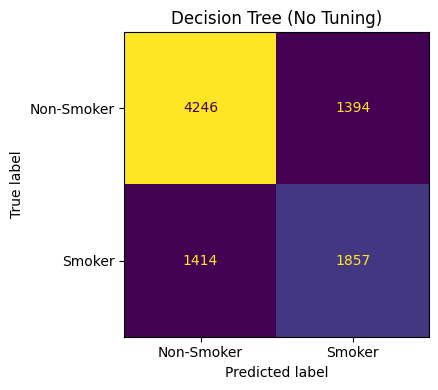


=== Decision Tree: With GridSearchCV Tuning ===
  Best params: {'max_depth': 5, 'min_samples_split': 2}

  Decision Tree (Tuned)
  Accuracy : 0.7411
  Precision: 0.6354
  Recall   : 0.6915
  F1 Score : 0.6623


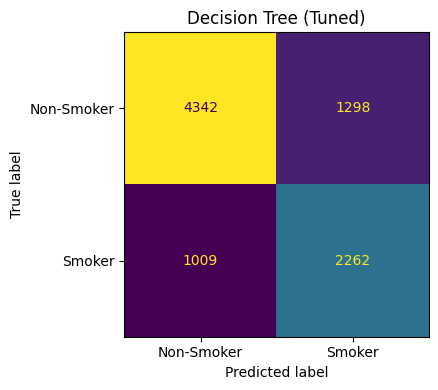

In [32]:
# ── DECISION TREE: Without Hyperparameter Tuning ──────────────────────────────
print("=== Decision Tree: No Tuning ===")
dt_no_tune = DecisionTreeClassifier(random_state=42)
dt_no_tune.fit(X_train, y_train)
r = evaluate("Decision Tree (No Tuning)", y_test, dt_no_tune.predict(X_test))
results.append(r)

# ── DECISION TREE: With Hyperparameter Tuning (GridSearchCV) ──────────────────
print("\n=== Decision Tree: With GridSearchCV Tuning ===")
dt_param_grid = {'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_param_grid, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)
print(f"  Best params: {grid_dt.best_params_}")
r = evaluate("Decision Tree (Tuned)", y_test, grid_dt.best_estimator_.predict(X_test))
results.append(r)

In [33]:
## Section 6: Supervised Models — Random Forest
# Train Random Forest with and without hyperparameter tuning using GridSearchCV.

=== Random Forest: No Tuning ===

  Random Forest (No Tuning)
  Accuracy : 0.7615
  Precision: 0.6669
  Recall   : 0.7001
  F1 Score : 0.6831


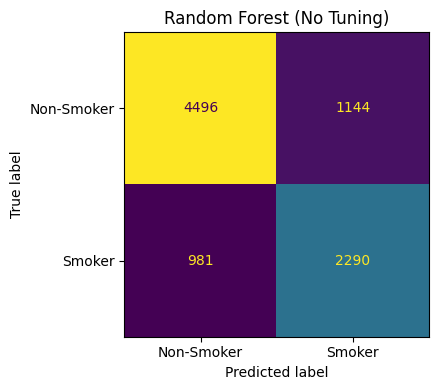


=== Random Forest: With GridSearchCV Tuning ===
  Best params: {'max_depth': 10, 'n_estimators': 100}

  Random Forest (Tuned)
  Accuracy : 0.7638
  Precision: 0.6588
  Recall   : 0.7395
  F1 Score : 0.6968


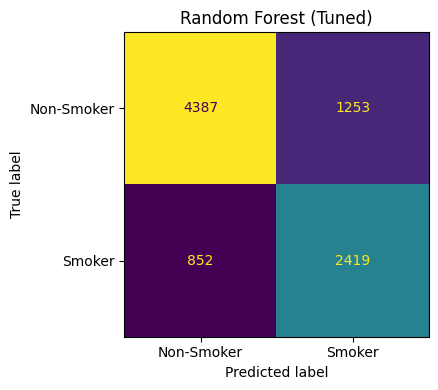

In [34]:
# ── RANDOM FOREST: Without Tuning ─────────────────────────────────────────────
print("=== Random Forest: No Tuning ===")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
r = evaluate("Random Forest (No Tuning)", y_test, rf.predict(X_test))
results.append(r)

# ── RANDOM FOREST: With Hyperparameter Tuning ─────────────────────────────────
print("\n=== Random Forest: With GridSearchCV Tuning ===")
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_param_grid, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print(f"  Best params: {grid_rf.best_params_}")
r = evaluate("Random Forest (Tuned)", y_test, grid_rf.best_estimator_.predict(X_test))
results.append(r)

In [35]:
## Section 7: Supervised Models — Logistic Regression
# Train Logistic Regression and evaluate with k-fold cross-validation (k=3,5,10).

=== Logistic Regression ===

  Logistic Regression
  Accuracy : 0.7493
  Precision: 0.6448
  Recall   : 0.7059
  F1 Score : 0.6740


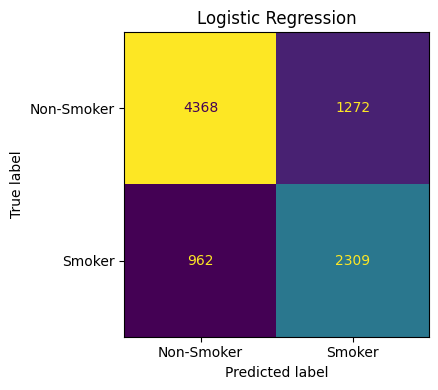


=== Logistic Regression: K-Fold CV ===
  k=3 -> F1 Mean: 0.6657, Std: 0.0033
  k=5 -> F1 Mean: 0.6644, Std: 0.0042
  k=10 -> F1 Mean: 0.6656, Std: 0.0056


In [36]:
# ── LOGISTIC REGRESSION ───────────────────────────────────────────────────────
print("=== Logistic Regression ===")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
r = evaluate("Logistic Regression", y_test, lr.predict(X_test))
results.append(r)

# K-Fold Cross-Validation
print("\n=== Logistic Regression: K-Fold CV ===")
for k in [3, 5, 10]:
    scores = cross_val_score(lr, X_scaled, y, cv=k, scoring='f1')
    print(f"  k={k} -> F1 Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

In [37]:
## Section 8: Supervised Models — Support Vector Machine (SVM)
# Train an SVM classifier. A stratified 20% training subset is used for
# computational efficiency given the large dataset size.

=== SVM ===
  Training SVM on 7128 rows...

  SVM
  Accuracy : 0.7506
  Precision: 0.6478
  Recall   : 0.7028
  F1 Score : 0.6742


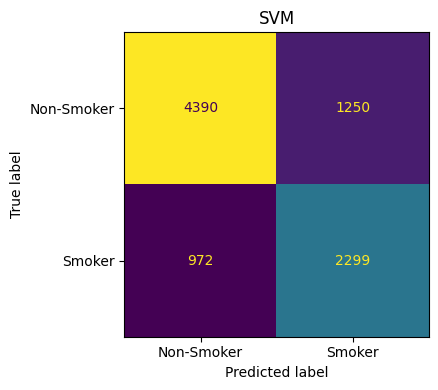

In [38]:
# ── SVM (trained on 20% subset for computational efficiency) ──────────────────
print("=== SVM ===")
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=0.2, random_state=42, stratify=y_train)
print(f"  Training SVM on {X_train_small.shape[0]} rows...")

svm = SVC(random_state=42, probability=True)
svm.fit(X_train_small, y_train_small)
r = evaluate("SVM", y_test, svm.predict(X_test))
results.append(r)

In [39]:
## Section 9: Unsupervised Model — K-Means Clustering
# Apply K-Means clustering with k=2 and evaluate using Silhouette Score,
# Adjusted Rand Index (ARI), and Adjusted Mutual Information (AMI).
# Visualise clusters using PCA dimensionality reduction.

In [40]:
# ── K-MEANS CLUSTERING ────────────────────────────────────────────────────────
print("=== K-Means Clustering (k=2) ===")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, cluster_labels)
ari = adjusted_rand_score(y, cluster_labels)
ami = adjusted_mutual_info_score(y, cluster_labels)

print(f"  Silhouette Score : {sil:.4f}")
print(f"  ARI              : {ari:.4f}")
print(f"  AMI              : {ami:.4f}")

=== K-Means Clustering (k=2) ===
  Silhouette Score : 0.1630
  ARI              : 0.1467
  AMI              : 0.1925


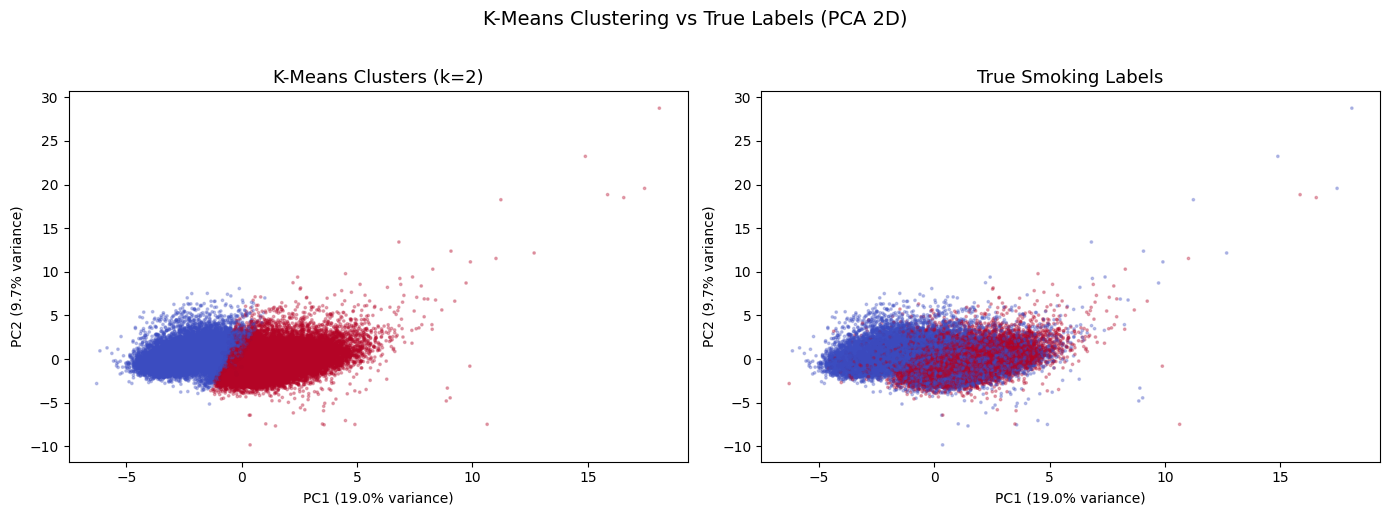

In [41]:
# ── K-MEANS: PCA VISUALISATION ────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: K-Means cluster labels
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                cmap='coolwarm', alpha=0.3, s=3)
axes[0].set_title('K-Means Clusters (k=2)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

# Right: True smoking labels
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y.values,
                cmap='coolwarm', alpha=0.3, s=3)
axes[1].set_title('True Smoking Labels', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

plt.suptitle('K-Means Clustering vs True Labels (PCA 2D)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
## Section 10: Ensemble Models
# Implement Bagging, AdaBoost, Gradient Boosting, Voting Classifier, and Stacking.
# Compare performance against individual base models.

=== Bagging ===

  Bagging
  Accuracy : 0.7482
  Precision: 0.6509
  Recall   : 0.6772
  F1 Score : 0.6638


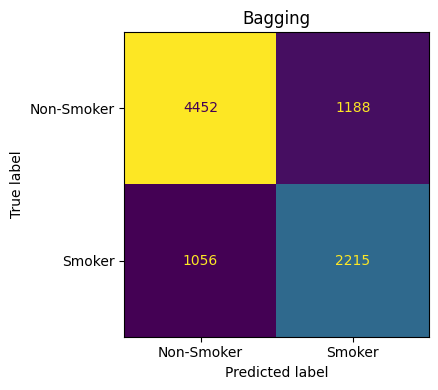


=== AdaBoost ===

  AdaBoost
  Accuracy : 0.7541
  Precision: 0.6582
  Recall   : 0.6869
  F1 Score : 0.6723


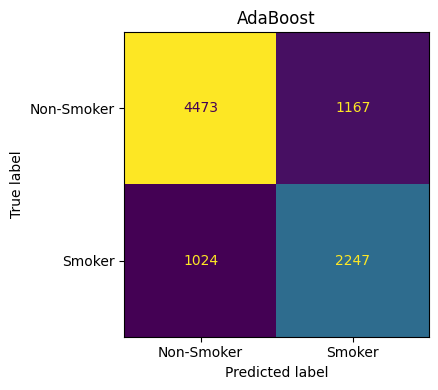


=== Gradient Boosting ===

  Gradient Boosting
  Accuracy : 0.7604
  Precision: 0.6579
  Recall   : 0.7236
  F1 Score : 0.6892


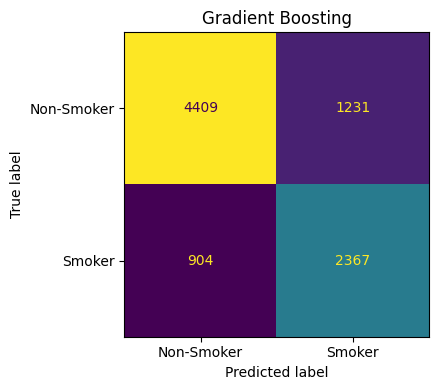

In [43]:
# ── BAGGING ───────────────────────────────────────────────────────────────────
print("=== Bagging ===")
bagging = BaggingClassifier(random_state=42, n_estimators=50)
bagging.fit(X_train, y_train)
r = evaluate("Bagging", y_test, bagging.predict(X_test))
results.append(r)

# ── ADABOOST ──────────────────────────────────────────────────────────────────
print("\n=== AdaBoost ===")
ada = AdaBoostClassifier(random_state=42, n_estimators=50)
ada.fit(X_train, y_train)
r = evaluate("AdaBoost", y_test, ada.predict(X_test))
results.append(r)

# ── GRADIENT BOOSTING ─────────────────────────────────────────────────────────
print("\n=== Gradient Boosting ===")
gb = GradientBoostingClassifier(random_state=42, n_estimators=50)
gb.fit(X_train, y_train)
r = evaluate("Gradient Boosting", y_test, gb.predict(X_test))
results.append(r)

=== Voting Classifier (soft voting: DT + LR + RF) ===

  Voting Classifier
  Accuracy : 0.7089
  Precision: 0.6068
  Recall   : 0.5879
  F1 Score : 0.5972


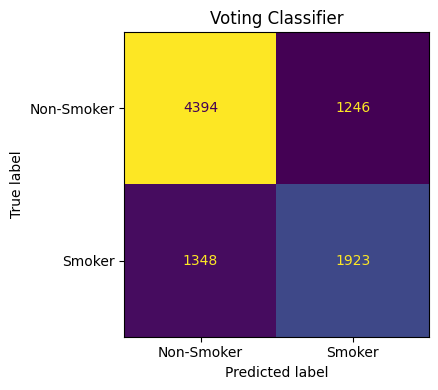


=== Stacking (DT + LR + SVM -> RF meta-learner) ===
  Training stacking on 7128 rows...

  Stacking
  Accuracy : 0.7169
  Precision: 0.6157
  Recall   : 0.6084
  F1 Score : 0.6120


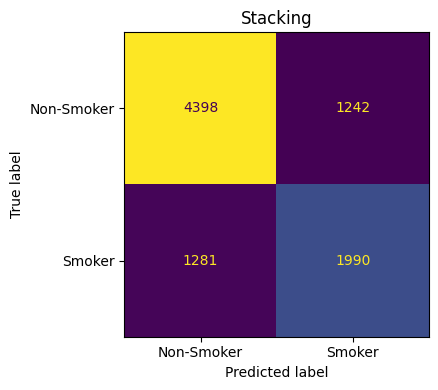

In [44]:
# ── VOTING CLASSIFIER ─────────────────────────────────────────────────────────
print("=== Voting Classifier (soft voting: DT + LR + RF) ===")
voting = VotingClassifier(estimators=[
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=50))
], voting='soft')
voting.fit(X_train, y_train)
r = evaluate("Voting Classifier", y_test, voting.predict(X_test))
results.append(r)

# ── STACKING (20% subset for computational efficiency) ────────────────────────
print("\n=== Stacking (DT + LR + SVM -> RF meta-learner) ===")
X_train_small, _, y_train_small, _ = train_test_split(
    X_train, y_train, train_size=0.2, random_state=42, stratify=y_train)
print(f"  Training stacking on {X_train_small.shape[0]} rows...")

stacking = StackingClassifier(estimators=[
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(random_state=42, probability=True))
], final_estimator=RandomForestClassifier(random_state=42))
stacking.fit(X_train_small, y_train_small)
r = evaluate("Stacking", y_test, stacking.predict(X_test))
results.append(r)

In [45]:
## Section 11: Results Summary and Visualisation
# Display a final summary table of all model performances sorted by F1 score,
# and plot an F1 score comparison bar chart.

In [46]:
# ── CLEAN RESULTS SUMMARY TABLE ───────────────────────────────────────────────
results_df = (pd.DataFrame(results)
              .drop_duplicates(subset='Model')
              .sort_values('F1', ascending=False)
              .reset_index(drop=True))

print("=== FINAL RESULTS SUMMARY (sorted by F1) ===")
print(results_df.to_string(index=False))

=== FINAL RESULTS SUMMARY (sorted by F1) ===
                    Model  Accuracy  Precision  Recall     F1
    Random Forest (Tuned)    0.7638     0.6588  0.7395 0.6968
        Gradient Boosting    0.7604     0.6579  0.7236 0.6892
Random Forest (No Tuning)    0.7615     0.6669  0.7001 0.6831
                      SVM    0.7506     0.6478  0.7028 0.6742
      Logistic Regression    0.7493     0.6448  0.7059 0.6740
                 AdaBoost    0.7541     0.6582  0.6869 0.6723
                  Bagging    0.7482     0.6509  0.6772 0.6638
    Decision Tree (Tuned)    0.7411     0.6354  0.6915 0.6623
                 Stacking    0.7169     0.6157  0.6084 0.6120
        Voting Classifier    0.7089     0.6068  0.5879 0.5972
Decision Tree (No Tuning)    0.6849     0.5712  0.5677 0.5695


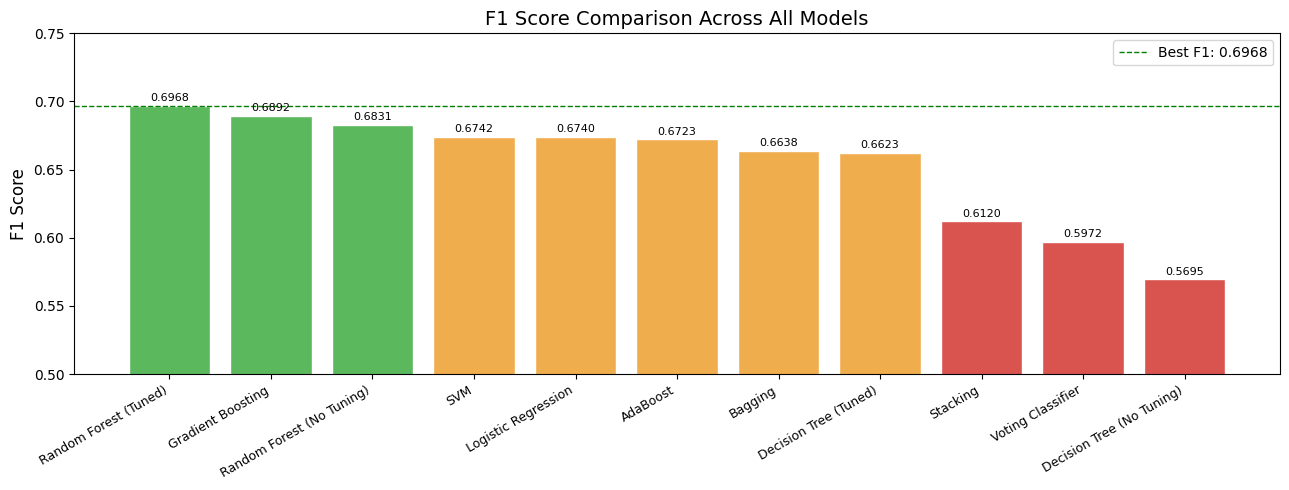

Saved: f1_comparison.png


In [47]:
# ── F1 SCORE COMPARISON BAR CHART ─────────────────────────────────────────────
model_names = results_df['Model'].tolist()
f1_scores   = results_df['F1'].tolist()

colors = ['#d9534f' if f < 0.65 else '#f0ad4e' if f < 0.68 else '#5cb85c'
          for f in f1_scores]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(model_names, f1_scores, color=colors, edgecolor='white')
ax.set_ylim(0.5, 0.75)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score Comparison Across All Models', fontsize=14)
ax.axhline(y=max(f1_scores), color='green', linestyle='--',
           linewidth=1, label=f'Best F1: {max(f1_scores)}')
plt.xticks(rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.legend()
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()
print("Saved: f1_comparison.png")